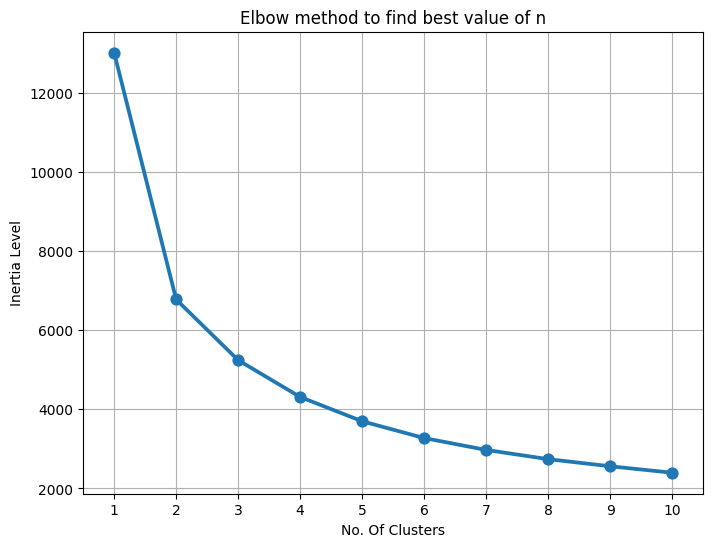

                              Recency          Frequency Monetary      
                                 mean  max min      mean     mean count
Cluster Segment                                                        
0       Champions               12.91   88   1    283.08  7042.88   867
1       At Risk Customers       96.35  374  18     80.24  1522.39  1222
2       Potential Loyalists     19.89   61   1     38.74   612.06   872
3       Hibernating Customers  185.29  374  14     14.97   298.59  1377


                  Segment     Metric     Value
0       At Risk Customers  Frequency  0.378684
1       At Risk Customers   Monetary  0.351984
2       At Risk Customers    Recency  0.379580
3               Champions  Frequency  1.252372
4               Champions   Monetary  1.288550
5               Champions    Recency -1.165290
6   Hibernating Customers  Frequency -0.979522
7   Hibernating Customers   Monetary -0.913568
8   Hibernating Customers    Recency  0.887844
9     Potential Loyalists  Frequency -0.229079
10    Potential Loyalists   Monetary -0.331783
11    Potential Loyalists    Recency -0.775345


Top 5 Products Purchased By Champions
Description
PAPER CRAFT , LITTLE BIRDIE          80995
WORLD WAR 2 GLIDERS ASSTD DESIGNS    37655
JUMBO BAG RED RETROSPOT              34985
POPCORN HOLDER                       26994
ASSORTED COLOUR BIRD ORNAMENT        24541
Name: Quantity, dtype: int64
Top 5 Products Purchased By At Risk Customers
Description
MEDIUM CERAMIC TOP STORAGE JAR        74892
PACK OF 72 RETROSPOT CAKE CASES       10550
WORLD WAR 2 GLIDERS ASSTD DESIGNS     10220
WHITE HANGING HEART T-LIGHT HOLDER     9301
JUMBO BAG RED RETROSPOT                7119
Name: Quantity, dtype: int64
Top 5 Products Purchased By Potential Loyalists
Description
SMALL CHINESE STYLE SCISSOR      8010
RABBIT NIGHT LIGHT               5543
SOMBRERO                         2603
ASSORTED COLOUR BIRD ORNAMENT    2521
T-LIGHT GLASS FLUTED ANTIQUE     2384
Name: Quantity, dtype: int64
Top 5 Products Purchased By Hibernating Customers
Description
ESSENTIAL BALM 3.5g TIN IN ENVELOPE    5586
BROCADE RING P

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the dataset
df = pd.read_csv('online_retail.csv')
df_copy = df.copy()

#Data Cleaning
df_copy = df_copy.dropna(subset=['CustomerID'])
df_copy = df_copy.dropna(subset=['Description'])

df_copy = df_copy[df_copy['Quantity'] > 0]
df_copy = df_copy[df_copy['UnitPrice'] > 0]

df_copy = df_copy[df_copy['InvoiceNo'].str.startswith('C') == False]
df_copy['TotalPrice'] = df_copy['Quantity'] * df_copy['UnitPrice']



# print(df.info())
# print(df.describe())
# print("\nMissing values:")
# print(df.isnull().sum())
# df.head()

#datetime
df_copy['InvoiceDate'] = pd.to_datetime(df_copy['InvoiceDate'])
snapshot_date = df_copy['InvoiceDate'].max() + dt.timedelta(days=1)

#Recency Frequency Monetary
rfm = df_copy.groupby("CustomerID").agg({
    'InvoiceDate': (lambda x:(snapshot_date - x.max()).days), #Recency
    'InvoiceNo': 'count', #Frequency
    'TotalPrice': 'sum' #Monetary
})

rfm.rename(columns={
    'InvoiceDate' : 'Recency',
    'InvoiceNo' : 'Frequency',
    'TotalPrice' : 'Monetary',
    
},
inplace=True
)

#Scaling and Log Transformation
rfm_log = np.log(rfm +1)
scaler =  StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index,columns = rfm.columns)

#finding the no. of clusters

sse = {}
for n in range(1,11) : 
    kmeans = KMeans(n_clusters=n,random_state=42,n_init=50)
    kmeans.fit(rfm_scaled_df)
    sse[n] = kmeans.inertia_

plt.figure(figsize=(8,6))
plt.title("Elbow method to find best value of n")

plt.xlabel("No. Of Clusters")
plt.ylabel("Inertia Level")

sns.pointplot(x=list(sse.keys()),y=list(sse.values()))

plt.grid(True)
plt.show()

kmeans = KMeans(n_clusters=4,random_state=42,n_init=50,init='k-means++')
rfm_scaled_df['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

rfm['Cluster'] = kmeans.labels_

segment_names = {
    0 : "Champions",
    1 : "At Risk Customers",
    2 : "Potential Loyalists",
    3 : "Hibernating Customers"
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

# Set legend order for Segment
segment_order = ["Champions", "At Risk Customers", "Potential Loyalists", "Hibernating Customers"]


cluster_profile = rfm.groupby(['Cluster', 'Segment']).agg(
    {
        'Recency'  : ["mean","max","min"],
        'Frequency' :"mean",
        'Monetary' : ["mean","count"]

    }
).round(2)


print(cluster_profile.head())


segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']
fig_pie = px.pie(
    segment_counts,
    values='Count',
    names='Segment',
    title="Customer Distribution by Segment",
    color_discrete_map={
    "Champions": "#2ecc71",
    "At Risk Customers": "#e74c3c",
    "Potential Loyalists": "#3498db",
    "Hibernating Customers": "#95a5a6"
    }
)

fig_pie.show()

# We use the dataframe that has both the coordinates and the labels
fig = px.scatter_3d(rfm, 
                    x='Recency', 
                    y='Frequency', 
                    z='Monetary',
                    color='Segment', # Colors dots by Segment name
                    hover_name=rfm.index, # Shows CustomerID when you hover
                    title='<b> Interactive 3D Customer Segments </b>',
                    category_orders={'Segment': ["Champions", "At Risk Customers", "Potential Loyalists", "Hibernating Customers"]})
fig.update_layout(scene = dict(
                    xaxis_title='Recency',
                    yaxis_title='Frequency',
                    zaxis_title='Monetary'),
                    legend_title='Customer Segment')


fig.show()



#snake plot
rfm_scaled_df["Cluster"] = rfm["Cluster"]
rfm_scaled_df["Segment"] = rfm["Segment"]
rfm_scaled_df["CustomerID"] = rfm.index

melted_df = pd.melt(
    rfm_scaled_df,
    id_vars=["CustomerID","Cluster","Segment"],
    value_vars=["Recency","Frequency","Monetary"],
    var_name="Metric",
    value_name="Value",

)

df_snake = melted_df.groupby(["Segment","Metric"])["Value"].mean().reset_index()

print(df_snake)
fig_snake = px.line(
    df_snake,
    x="Metric",
    y="Value",
    color="Segment",
    markers=True,
    category_orders={'Metric' : ["Champions", "At Risk Customers","Potential Loyalist", "Hibernating Customers"]},
    title="<b> Customer Segment Fingerprint </b>"

)

fig_snake.update_layout(
    xaxis_title="Metric",
    yaxis_title="Value",
    legend_title="Customer Segment"
)


fig_snake.show()

#Supply Chain Optimization
supply_chain_df = df_copy.merge(rfm[["Segment"]],on="CustomerID")

champions_products = supply_chain_df[supply_chain_df["Segment"]=="Champions"]

top_champion_products = champions_products.groupby("Description")["Quantity"].sum().sort_values(ascending=False)
print("Top 5 Products Purchased By Champions")
print(top_champion_products.head())

Atrisk_products = supply_chain_df[supply_chain_df["Segment"]=="At Risk Customers"]


top_at_risk_products = Atrisk_products.groupby("Description")["Quantity"].sum().sort_values(ascending=False)
print("Top 5 Products Purchased By At Risk Customers")
print(top_at_risk_products.head())

Potential_loyalists_products = supply_chain_df[supply_chain_df["Segment"]=="Potential Loyalists"]


top_potential_loyalists_products = Potential_loyalists_products.groupby("Description")["Quantity"].sum().sort_values(ascending=False)
print("Top 5 Products Purchased By Potential Loyalists")
print(top_potential_loyalists_products.head())

Hibernating_customers_products = supply_chain_df[supply_chain_df["Segment"]=="Hibernating Customers"]
top_hibernating_customers_products = Hibernating_customers_products.groupby("Description")["Quantity"].sum().sort_values(ascending=False)
print("Top 5 Products Purchased By Hibernating Customers")
print(top_hibernating_customers_products.head())

product_by_segment = supply_chain_df.groupby(["Description", "Segment"])["Quantity"].sum().reset_index()
top_overall_products = supply_chain_df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10).index
comparison_df = product_by_segment[product_by_segment["Description"].isin(top_overall_products)]
 
fig_comparison = px.bar(
        comparison_df,
        x="Description",
        y="Quantity",
        color="Segment",
        title="Top 10 Products - Segment Comparison",
        color_discrete_map={
            "Champions": "#2ecc71",
            "At Risk Customers": "#e74c3c",
            "Potential Loyalists": "#3498db",
            "Hibernating Customers": "#95a5a6"
        },
        barmode='group'
    )

fig_comparison.show()







